In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans , DBSCAN
from sklearn.preprocessing import StandardScaler

In [18]:
X , y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [19]:
df = pd.DataFrame(X,columns=['feature_1','feature_2'])

In [20]:
df.head()

,feature_1,feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868


In [21]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(df)

In [23]:
inertia = []
K_range = range(1,11)



In [24]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [25]:
inertia

[999.9999999999999,
 528.8064432605653,
 294.43770686781875,
 250.4552469653446,
 216.88110656982616,
 185.27440675195922,
 156.70879996290455,
 135.62603453115253,
 129.1039634823982,
 119.94101297105001]

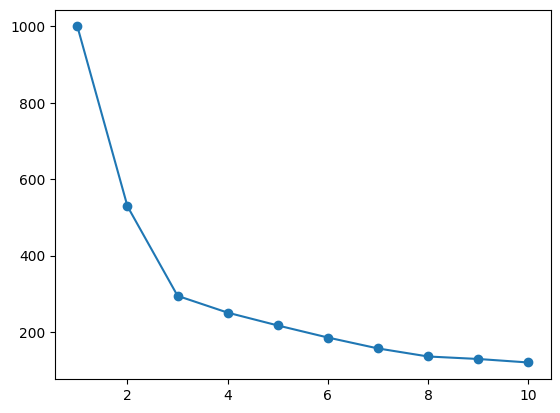

In [26]:
plt.plot(K_range,inertia,marker='o')

In [27]:
kmeans_final = KMeans(n_clusters=3, random_state=42)


In [28]:
cluster_labels = kmeans_final.fit_predict(x_scaled)

In [30]:
df['cluster'] = cluster_labels

In [31]:
df.head()

,feature_1,feature_2,cluster
0,-2.282534,-9.692815,1
1,-6.147668,1.755990,2
2,13.399091,-1.260023,0
3,-4.077630,3.160226,2
4,9.444735,0.340868,0


<Axes: xlabel='feature_1', ylabel='feature_2'>

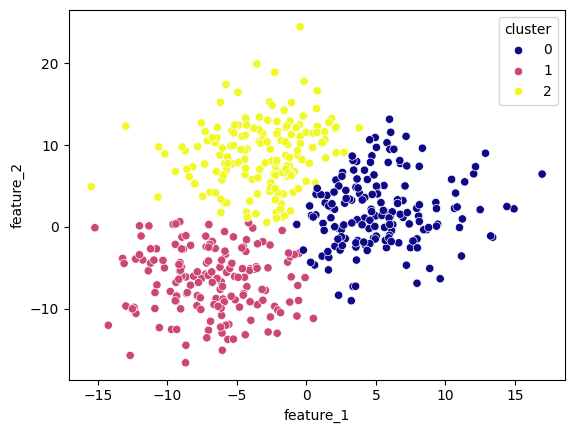

In [33]:
sns.scatterplot(data=df,x='feature_1',y='feature_2',hue='cluster',palette='plasma')

In [34]:
from sklearn.datasets import make_moons

In [35]:
X , y_true = make_moons(n_samples=500, noise=0.05 , random_state=42)

In [36]:
df = pd.DataFrame(X,columns=['feature_1','feature_2'])

In [38]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [39]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_label = kmeans.fit_predict(x_scaled)

In [40]:
df['kmeans_cluster'] = kmeans_label

In [41]:
df.head()

,feature_1,feature_2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


<Axes: xlabel='feature_1', ylabel='feature_2'>

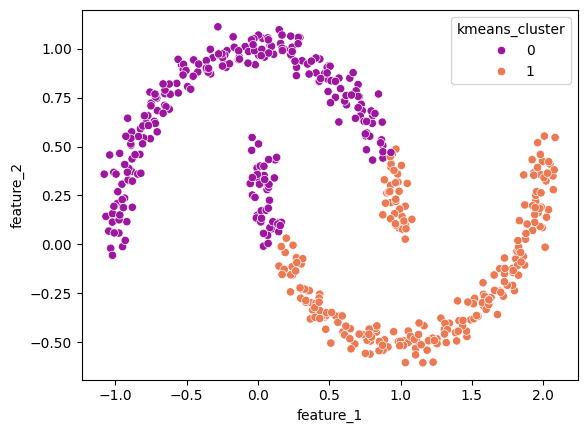

In [43]:
sns.scatterplot(data=df,x='feature_1',y='feature_2',hue='kmeans_cluster',palette='plasma')

In [44]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

In [45]:
df['dbscan_cluster'] = dbscan_labels

In [46]:
df.head()

,feature_1,feature_2,kmeans_cluster,dbscan_cluster
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1


<Axes: xlabel='feature_1', ylabel='feature_2'>

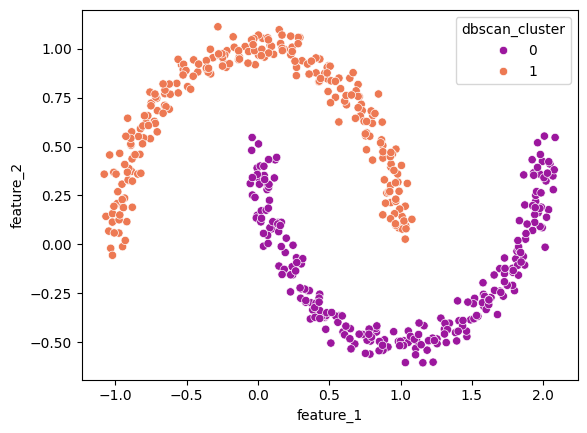

In [48]:
sns.scatterplot(data=df,x='feature_1',y='feature_2',hue='dbscan_cluster',palette='plasma')